# Домашнее задание к семинару 12 (HW12)

Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

In [1]:
# Системные импорты
import os
import random
import json
import warnings
from datetime import datetime

# Научные вычисления
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# PyTorch и нейросети
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Отключение предупреждений
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Установка рабочей директории
base_dir = '/content/drive/MyDrive/seminars/S12'
os.chdir(base_dir)

print("Текущая директория:", os.getcwd())

# Создание папок для артефактов
os.makedirs('artifacts', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")
print(f"PyTorch версия: {torch.__version__}")

Mounted at /content/drive
Текущая директория: /content/drive/MyDrive/seminars/S12
Используется устройство: cuda
PyTorch версия: 2.10.0+cu128


#### 2.3.2. Данные и первичный анализ

1) Загрузить `S12-hw-dataset.csv`.
2) Привести `date` к datetime и отсортировать строки по времени.
3) Показать:
   - число наблюдений;
   - диапазон дат;
   - число пропусков по колонкам;
   - базовый график временного ряда.
4) Кратко прокомментировать ряд: тренд, сезонность, выбросы, возможную нестационарность.

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')


Информация о данных
Число наблюдений: 4320
Диапазон дат: с 2025-01-01 00:00:00 по 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


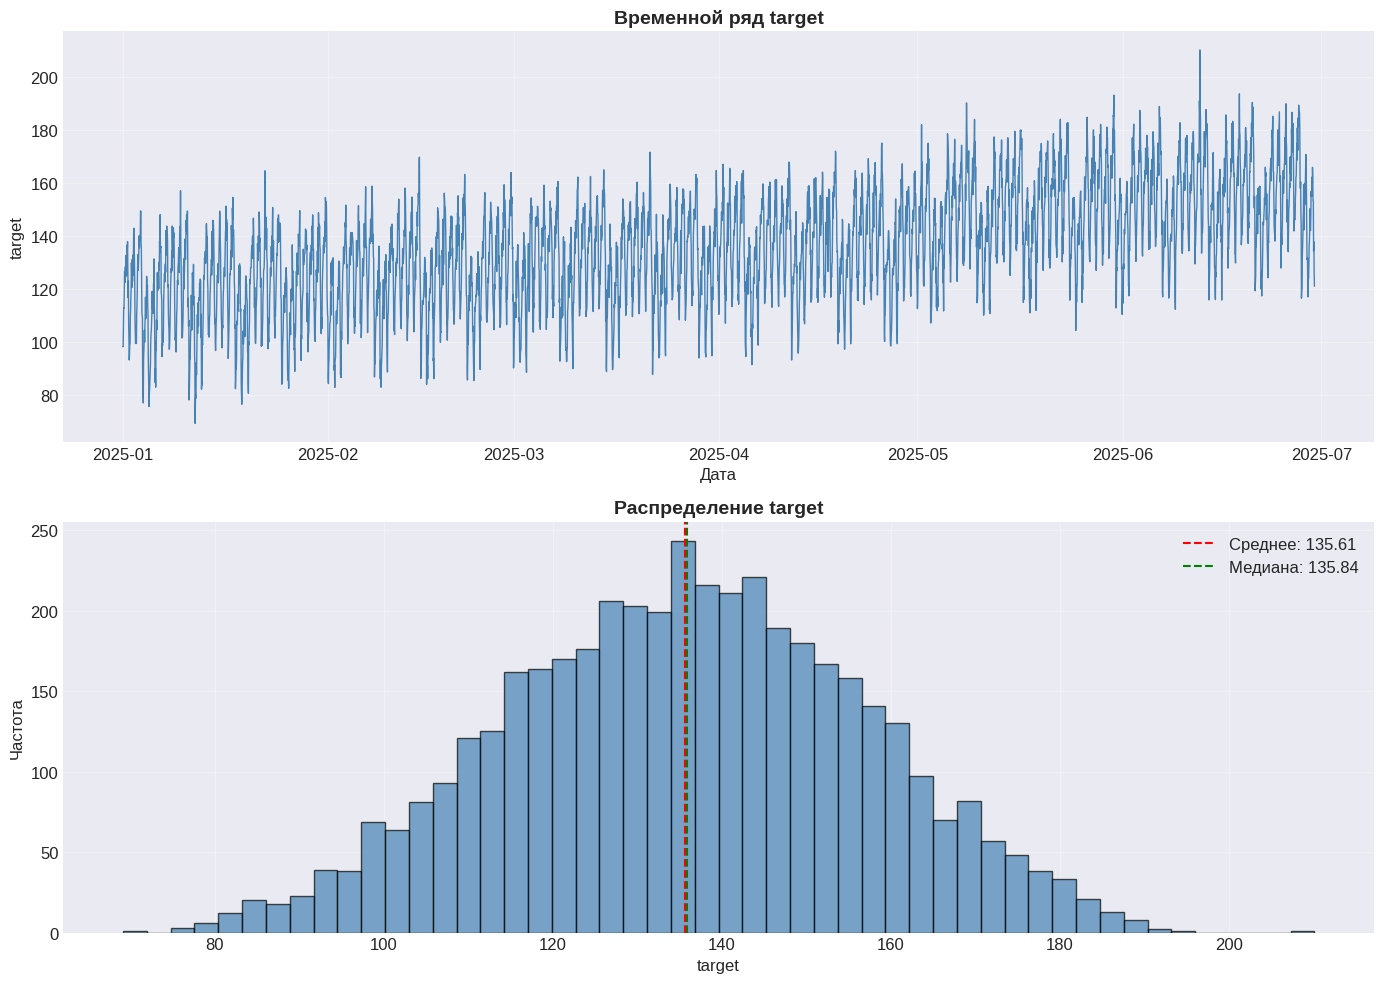


Комментарии к ряду
1. Тренд: Наблюдается четкий восходящий тренд от января (значения ~70-100) к июню (значения ~150-210).
   Особенно сильный рост заметен в мае-июне, где ряд достигает максимальных значений (210.1).

2. Сезонность: Присутствуют регулярные внутридневные колебания с периодом 24 часа.
   Видны четкие дневные циклы: значения растут днем и снижаются ночью.

3. Выбросы: Есть значительные пики (максимум 210.1 в июне) и провалы (минимум 69.1 в январе).
   Разброс значений увеличивается к концу периода (гетероскедастичность).

4. Нестационарность: Ряд явно нестационарен по нескольким причинам:
   - Наличие восходящего тренда
   - Изменяющаяся дисперсия (волатильность растет к концу периода)
   - Сезонные колебания, меняющие амплитуду

5. Статистика распределения:
   - Диапазон значений: от 69.1 до 210.1
   - Среднее значение: 135.61
   - Медиана: 135.84
   - Стандартное отклонение: 21.38
   - Коэффициент вариации (CV): 15.8%

6. Квартили:
   - 25-й перцентиль: 120.54
   - 75-й

In [4]:
# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Показать информацию
print("\nИнформация о данных")
print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: с {df['date'].min()} по {df['date'].max()}")
print(f"\nПропуски по колонкам:")
print(df.isnull().sum())
print(f"\nСтатистика target:")
print(df['target'].describe())

# Базовый график временного ряда
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График ряда
axes[0].plot(df['date'], df['target'], linewidth=1, color='steelblue')
axes[0].set_title('Временной ряд target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('target')
axes[0].grid(True, alpha=0.3)

# Гистограмма распределения
axes[1].hist(df['target'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('target')
axes[1].set_ylabel('Частота')
axes[1].axvline(df['target'].mean(), color='red', linestyle='--', label=f'Среднее: {df["target"].mean():.2f}')
axes[1].axvline(df['target'].median(), color='green', linestyle='--', label=f'Медиана: {df["target"].median():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png', dpi=150, bbox_inches='tight')
plt.show()

# Комментарии к ряду
print("\nКомментарии к ряду")

print("1. Тренд: Наблюдается четкий восходящий тренд от января (значения ~70-100) к июню (значения ~150-210).")
print("   Особенно сильный рост заметен в мае-июне, где ряд достигает максимальных значений (210.1).")
print()
print("2. Сезонность: Присутствуют регулярные внутридневные колебания с периодом 24 часа.")
print("   Видны четкие дневные циклы: значения растут днем и снижаются ночью.")
print()
print("3. Выбросы: Есть значительные пики (максимум 210.1 в июне) и провалы (минимум 69.1 в январе).")
print("   Разброс значений увеличивается к концу периода (гетероскедастичность).")
print()
print("4. Нестационарность: Ряд явно нестационарен по нескольким причинам:")
print("   - Наличие восходящего тренда")
print("   - Изменяющаяся дисперсия (волатильность растет к концу периода)")
print("   - Сезонные колебания, меняющие амплитуду")
print()
print("5. Статистика распределения:")
print(f"   - Диапазон значений: от {df['target'].min():.1f} до {df['target'].max():.1f}")
print(f"   - Среднее значение: {df['target'].mean():.2f}")
print(f"   - Медиана: {df['target'].median():.2f}")
print(f"   - Стандартное отклонение: {df['target'].std():.2f}")
print(f"   - Коэффициент вариации (CV): {(df['target'].std()/df['target'].mean()*100):.1f}%")
print()
print("6. Квартили:")
print(f"   - 25-й перцентиль: {df['target'].quantile(0.25):.2f}")
print(f"   - 75-й перцентиль: {df['target'].quantile(0.75):.2f}")
print(f"   - Межквартильный размах (IQR): {df['target'].quantile(0.75) - df['target'].quantile(0.25):.2f}")
print()
print("7. Асимметрия: Распределение близко к симметричному (среднее ≈ медиане),")
print("   но есть легкая правосторонняя асимметрия из-за высоких пиков в конце периода.")


**Корректный temporal split (2.3.3)**


Temporal Split
Общее количество наблюдений: 4320
Train: 2592 (60.0%)
Validation: 864 (20.0%)
Test: 864 (20.0%)

Границы split:
Train: 2025-01-01 00:00:00 -> 2025-04-18 23:00:00
Validation: 2025-04-19 00:00:00 -> 2025-05-24 23:00:00
Test: 2025-05-25 00:00:00 -> 2025-06-29 23:00:00


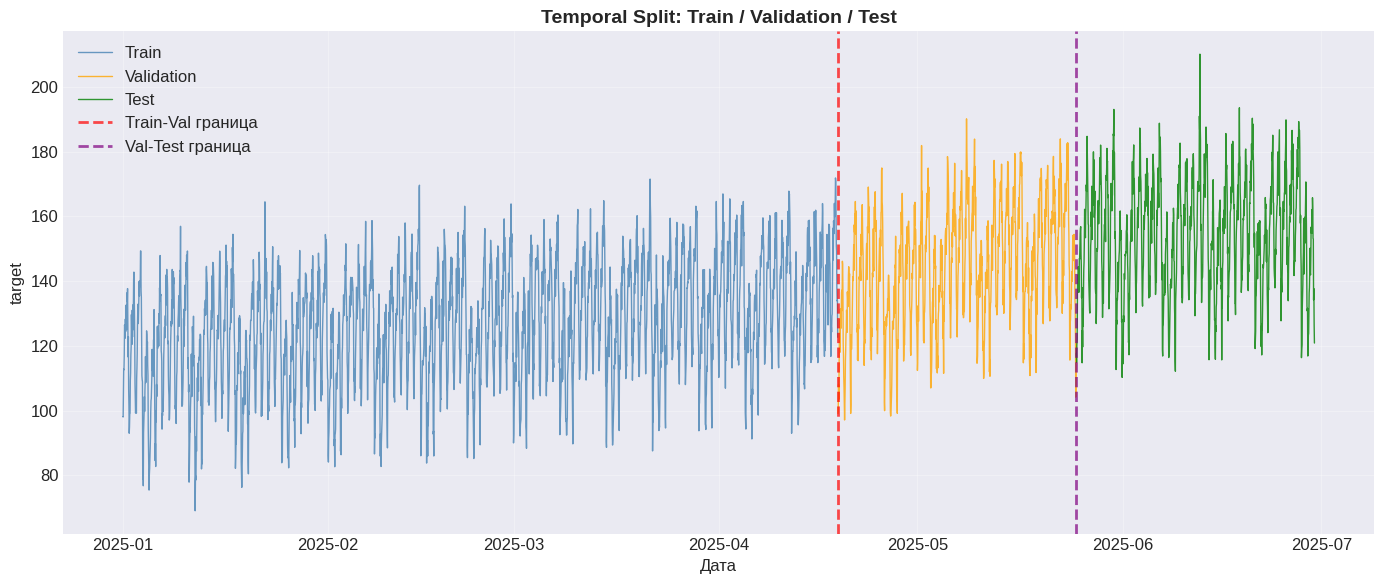


Почему random split некорректен для временных рядов?

1. Временная зависимость: Значения ряда зависят от предыдущих наблюдений (автокорреляция)
2. Random split нарушает временную структуру, перемешивая прошлое и будущее
3. Это приводит к утечке информации из будущего в обучающую выборку
4. Модель будет искусственно завышать качество, так как "знает" будущее
5. В реальных задачах мы прогнозируем только будущее на основе прошлого
6. Поэтому необходимо использовать temporal split, сохраняющий хронологический порядок



In [5]:
#Корректный temporal split

# Разбиение по времени (60% train, 20% val, 20% test)
n = len(df)
train_size = int(n * 0.6)
val_size = int(n * 0.2)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size+val_size].copy()
test_df = df.iloc[train_size+val_size:].copy()

print("Temporal Split")
print(f"Общее количество наблюдений: {n}")
print(f"Train: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/n*100:.1f}%)")

print(f"\nГраницы split:")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Validation: {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Test: {test_df['date'].min()} -> {test_df['date'].max()}")

# Визуализация split
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train_df['date'], train_df['target'], label='Train', color='steelblue', alpha=0.8, linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', color='orange', alpha=0.8, linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', color='green', alpha=0.8, linewidth=1)

# Вертикальные линии для границ
ax.axvline(x=train_df['date'].iloc[-1], color='red', linestyle='--', alpha=0.7, linewidth=2, label='Train-Val граница')
ax.axvline(x=val_df['date'].iloc[-1], color='purple', linestyle='--', alpha=0.7, linewidth=2, label='Val-Test граница')

ax.set_title('Temporal Split: Train / Validation / Test', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Объяснение
print("\nПочему random split некорректен для временных рядов?")
print("""
1. Временная зависимость: Значения ряда зависят от предыдущих наблюдений (автокорреляция)
2. Random split нарушает временную структуру, перемешивая прошлое и будущее
3. Это приводит к утечке информации из будущего в обучающую выборку
4. Модель будет искусственно завышать качество, так как "знает" будущее
5. В реальных задачах мы прогнозируем только будущее на основе прошлого
6. Поэтому необходимо использовать temporal split, сохраняющий хронологический порядок
""")

**Признаки для baseline-моделей (2.3.4)**

Создание признаков
Train после создания признаков: (2578, 17)
Validation после создания признаков: (850, 17)
Test после создания признаков: (850, 17)

Создано признаков: 15
Список признаков: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'hour', 'day_of_week', 'month', 'day_of_month', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']


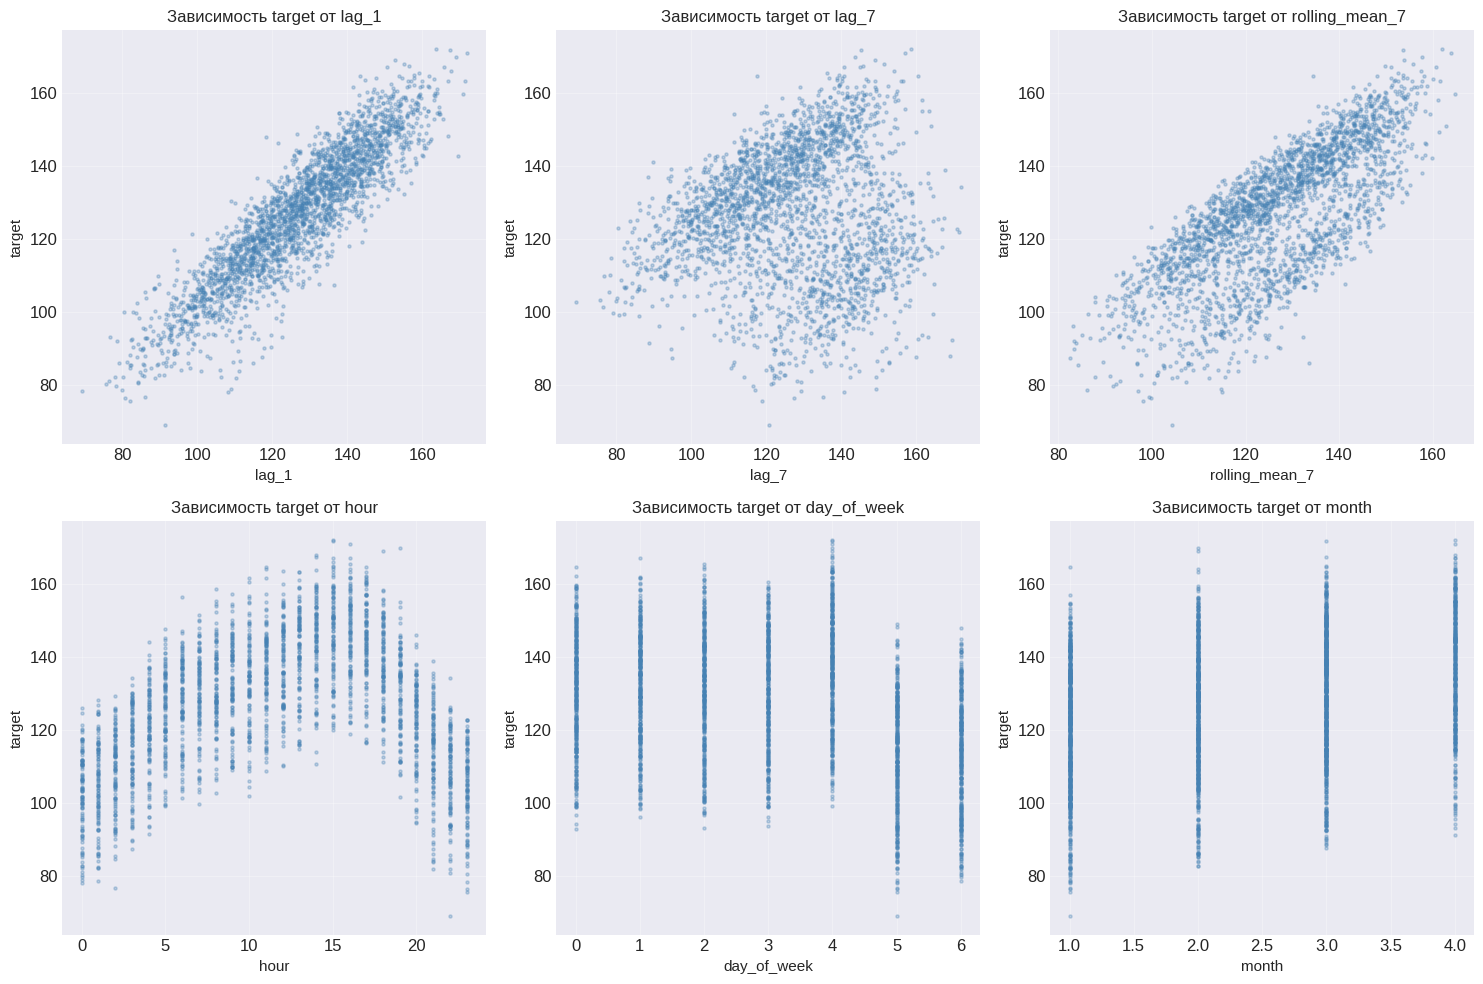

In [8]:
def create_features(df, window_sizes=[7, 14]):
    """Создание лаговых, rolling и календарных признаков"""
    df = df.copy()

    # Лаговые признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)

    # Rolling статистики
    for w in window_sizes:
        df[f'rolling_mean_{w}'] = df['target'].rolling(window=w, min_periods=1).mean()
        df[f'rolling_std_{w}'] = df['target'].rolling(window=w, min_periods=1).std()

    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day

    # Циклическое кодирование для временных признаков
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df

# Создание признаков для train, val, test отдельно (без утечки данных)
train_features = create_features(train_df).dropna().reset_index(drop=True)
val_features = create_features(val_df).dropna().reset_index(drop=True)
test_features = create_features(test_df).dropna().reset_index(drop=True)

print("Создание признаков")
print(f"Train после создания признаков: {train_features.shape}")
print(f"Validation после создания признаков: {val_features.shape}")
print(f"Test после создания признаков: {test_features.shape}")

feature_cols = [col for col in train_features.columns if col not in ['date', 'target']]
print(f"\nСоздано признаков: {len(feature_cols)}")
print(f"Список признаков: {feature_cols}")

# Визуализация некоторых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

feature_vis = ['lag_1', 'lag_7', 'rolling_mean_7', 'hour', 'day_of_week', 'month']
for i, feat in enumerate(feature_vis):
    axes[i].scatter(train_features[feat], train_features['target'], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('target', fontsize=11)
    axes[i].set_title(f'Зависимость target от {feat}', fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/feature_examples.png', dpi=150, bbox_inches='tight')
plt.show()

**Эксперимент B1 (naive-last)**

In [9]:
def calculate_metrics(y_true, y_pred):
    """Расчет метрик MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Подготовка данных
y_train = train_features['target']
y_val = val_features['target']
y_test = test_features['target']

# Прогноз = последнее значение из train
last_value = y_train.iloc[-1]
b1_val_pred = np.full(len(y_val), last_value)
b1_test_pred = np.full(len(y_test), last_value)

# Расчет метрик
b1_val_mae, b1_val_rmse, b1_val_mape = calculate_metrics(y_val, b1_val_pred)
b1_test_mae, b1_test_rmse, b1_test_mape = calculate_metrics(y_test, b1_test_pred)

print("Эксперимент B1 (Naive Baseline)")
print(f"Прогноз = последнее значение: {last_value:.2f}")
print(f"\nValidation:")
print(f"  MAE:  {b1_val_mae:.4f}")
print(f"  RMSE: {b1_val_rmse:.4f}")
print(f"  MAPE: {b1_val_mape:.2f}%")
print(f"\nTest:")
print(f"  MAE:  {b1_test_mae:.4f}")
print(f"  RMSE: {b1_test_rmse:.4f}")
print(f"  MAPE: {b1_test_mape:.2f}%")

Эксперимент B1 (Naive Baseline)
Прогноз = последнее значение: 122.68

Validation:
  MAE:  24.2565
  RMSE: 28.5575
  MAPE: 15.84%

Test:
  MAE:  32.2818
  RMSE: 36.2302
  MAPE: 19.94%


 **Эксперимент B2 (moving-average)**

In [23]:
def moving_average_forecast(y_train, y_val, window=7):
    """Прогноз на основе скользящего среднего последних window значений"""
    last_values = y_train.iloc[-window:].values
    predictions = np.full(len(y_val), np.mean(last_values))
    return predictions, np.mean(last_values)

# Прогноз с окном 7
b2_val_pred, avg_value = moving_average_forecast(y_train, y_val, window=7)
b2_test_pred, _ = moving_average_forecast(y_train, y_test, window=7)

# Расчет метрик
b2_val_mae, b2_val_rmse, b2_val_mape = calculate_metrics(y_val, b2_val_pred)
b2_test_mae, b2_test_rmse, b2_test_mape = calculate_metrics(y_test, b2_test_pred)

print("Эксперимент B2 (Moving Average Baseline)")
print(f"Окно = 7, среднее последних 7 значений: {avg_value:.2f}")
print(f"\nValidation:")
print(f"  MAE:  {b2_val_mae:.4f}")
print(f"  RMSE: {b2_val_rmse:.4f}")
print(f"  MAPE: {b2_val_mape:.2f}%")
print(f"\nTest:")
print(f"  MAE:  {b2_test_mae:.4f}")
print(f"  RMSE: {b2_test_rmse:.4f}")
print(f"  MAPE: {b2_test_mape:.2f}%")

# Проверка разных размеров окна
print("\nСравнение разных размеров окна на validation:")
for window in [3, 7, 14, 24]:
    pred, _ = moving_average_forecast(y_train, y_val, window)
    mae, rmse, mape = calculate_metrics(y_val, pred)
    print(f"  window={window}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}%")

Эксперимент B2 (Moving Average Baseline)
Окно = 7, среднее последних 7 значений: 141.18

Validation:
  MAE:  15.2734
  RMSE: 18.4072
  MAPE: 10.69%

Test:
  MAE:  18.0230
  RMSE: 21.8043
  MAPE: 11.19%

Сравнение разных размеров окна на validation:
  window=3: MAE=19.2099, RMSE=23.2017, MAPE=12.69%
  window=7: MAE=15.2734, RMSE=18.4072, MAPE=10.69%
  window=14: MAE=15.7174, RMSE=19.6564, MAPE=11.83%
  window=24: MAE=14.9629, RMSE=18.2948, MAPE=10.96%


**Эксперимент B3 (Ridge Regression)**

In [12]:
# Подготовка данных
X_train = train_features[feature_cols].values
X_val = val_features[feature_cols].values
X_test = test_features[feature_cols].values

y_train_ridge = train_features['target'].values
y_val_ridge = val_features['target'].values
y_test_ridge = test_features['target'].values

# Масштабирование (fit только на train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge с подбором alpha
print("Эксперимент B3 (Ridge Regression)")
print("Подбор оптимального alpha...")

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = 1.0
best_val_mae = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train_ridge)
    pred = ridge.predict(X_val_scaled)
    mae, rmse, mape = calculate_metrics(y_val_ridge, pred)
    print(f"  alpha={alpha}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}%")
    if mae < best_val_mae:
        best_val_mae = mae
        best_alpha = alpha

# Обучение с лучшим alpha
ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train_scaled, y_train_ridge)

# Прогнозы
b3_val_pred = ridge_best.predict(X_val_scaled)
b3_test_pred = ridge_best.predict(X_test_scaled)

b3_val_mae, b3_val_rmse, b3_val_mape = calculate_metrics(y_val_ridge, b3_val_pred)
b3_test_mae, b3_test_rmse, b3_test_mape = calculate_metrics(y_test_ridge, b3_test_pred)

print(f"\nЛучший alpha: {best_alpha}")
print(f"\nValidation:")
print(f"  MAE:  {b3_val_mae:.4f}")
print(f"  RMSE: {b3_val_rmse:.4f}")
print(f"  MAPE: {b3_val_mape:.2f}%")
print(f"\nTest:")
print(f"  MAE:  {b3_test_mae:.4f}")
print(f"  RMSE: {b3_test_rmse:.4f}")
print(f"  MAPE: {b3_test_mape:.2f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coef': ridge_best.coef_
}).sort_values('coef', key=abs, ascending=False)

print("\nТоп-10 наиболее важных признаков:")
print(feature_importance.head(10).to_string(index=False))

Эксперимент B3 (Ridge Regression)
Подбор оптимального alpha...
  alpha=0.01: MAE=4.7249, RMSE=6.0187, MAPE=3.29%
  alpha=0.1: MAE=4.7252, RMSE=6.0188, MAPE=3.29%
  alpha=1.0: MAE=4.7276, RMSE=6.0206, MAPE=3.29%
  alpha=10.0: MAE=4.7503, RMSE=6.0421, MAPE=3.31%
  alpha=100.0: MAE=4.9239, RMSE=6.2328, MAPE=3.41%

Лучший alpha: 0.01

Validation:
  MAE:  4.7249
  RMSE: 6.0187
  MAPE: 3.29%

Test:
  MAE:  4.8958
  RMSE: 6.2174
  MAPE: 3.17%

Топ-10 наиболее важных признаков:
        feature      coef
rolling_mean_14 11.079154
       hour_cos -6.686471
          lag_7 -5.729222
          lag_1  5.656441
         lag_14 -2.913135
    day_of_week -2.389066
       hour_sin  1.787382
           hour -1.695766
          month  1.404250
  rolling_std_7 -1.313608


**Оконное представление для GRU (2.3.5)**

In [24]:
class TimeSeriesDataset(Dataset):
    """Dataset для временных рядов"""
    def __init__(self, features, target, window_size):
        self.features = features
        self.target = target
        self.window_size = window_size

    def __len__(self):
        return len(self.features) - self.window_size

    def __getitem__(self, idx):
        x = self.features[idx:idx+self.window_size]
        y = self.target[idx+self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

def prepare_gru_data(train_df, val_df, test_df, feature_cols, target_col='target', window_size=24):
    """Подготовка данных для GRU"""
    # Извлечение данных
    X_train = train_df[feature_cols].values
    X_val = val_df[feature_cols].values
    X_test = test_df[feature_cols].values

    y_train = train_df[target_col].values
    y_val = val_df[target_col].values
    y_test = test_df[target_col].values

    # Масштабирование (fit только на train!)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    # Создание датасетов
    train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, window_size)
    val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, window_size)
    test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, window_size)

    return train_dataset, val_dataset, test_dataset, scaler_y, scaler_X

# Параметры
WINDOW_SIZE = 24  # 24 часа
BATCH_SIZE = 64

# Подготовка данных
train_dataset, val_dataset, test_dataset, scaler_y, scaler_X = prepare_gru_data(
    train_features, val_features, test_features,
    feature_cols=feature_cols,
    window_size=WINDOW_SIZE
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Подготовка данных для GRU")
print(f"Размер train: {len(train_dataset)}")
print(f"Размер val: {len(val_dataset)}")
print(f"Размер test: {len(test_dataset)}")
print(f"Количество признаков: {len(feature_cols)}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Форма одного батча: {next(iter(train_loader))[0].shape}")

Подготовка данных для GRU
Размер train: 2554
Размер val: 826
Размер test: 826
Количество признаков: 15
Window size: 24
Batch size: 64
Форма одного батча: torch.Size([64, 24, 15])


**Определение GRU модели**

In [25]:
class GRUForecaster(nn.Module):
    """GRU модель для прогнозирования временного ряда"""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]  # Берем последний выход
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Параметры модели
input_size = len(feature_cols)
hidden_size = 128
num_layers = 2
dropout = 0.2
learning_rate = 0.001
num_epochs = 100

# Инициализация
model = GRUForecaster(input_size, hidden_size, num_layers, dropout).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("=== Архитектура GRU ===")
print(f"Input size: {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"Number of layers: {num_layers}")
print(f"Dropout: {dropout}")
print(f"Learning rate: {learning_rate}")
print(f"Number of epochs: {num_epochs}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"\nМодель:")
print(model)

=== Архитектура GRU ===
Input size: 15
Hidden size: 128
Number of layers: 2
Dropout: 0.2
Learning rate: 0.001
Number of epochs: 100
Total parameters: 154881

Модель:
GRUForecaster(
  (gru): GRU(15, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


**Функции обучения и оценки (2.3.6)**

In [26]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    """Оценка модели"""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            predictions.extend(outputs.cpu().numpy())
            targets.extend(y_batch.cpu().numpy())

    mse = total_loss / len(loader)
    return mse, np.array(predictions), np.array(targets)

**Обучение GRU и сохранение лучшей модели**

In [35]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

print("=== Обучение GRU ===")
print("Начало обучения...\n")

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print(f"Лучшая валидационная потеря: {best_val_loss:.6f}")

# Загрузка лучшей модели
model.load_state_dict(best_model_state)

# Сохранение модели
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("Модель сохранена в artifacts/best_gru.pt")

# Сохранение конфига
model_config = {
    'input_size': input_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'dropout': dropout,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': learning_rate,
    'num_epochs': num_epochs,
    'best_val_loss': best_val_loss,
    'seed': 42,
    'feature_cols': feature_cols,
    'device': str(device),
    'optimizer': 'Adam',
    'loss_function': 'MSELoss',
    'model_type': 'GRUForecaster'
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print("Конфиг сохранен в artifacts/best_gru_config.json")

=== Обучение GRU ===
Начало обучения...

Epoch [10/100] | Train Loss: 0.052808 | Val Loss: 0.222941
Epoch [20/100] | Train Loss: 0.053928 | Val Loss: 0.199320
Epoch [30/100] | Train Loss: 0.054078 | Val Loss: 0.283866
Epoch [40/100] | Train Loss: 0.045327 | Val Loss: 0.251044
Epoch [50/100] | Train Loss: 0.047255 | Val Loss: 0.240233
Epoch [60/100] | Train Loss: 0.043095 | Val Loss: 0.229330
Epoch [70/100] | Train Loss: 0.057815 | Val Loss: 0.249280
Epoch [80/100] | Train Loss: 0.038803 | Val Loss: 0.232673
Epoch [90/100] | Train Loss: 0.039863 | Val Loss: 0.218601
Epoch [100/100] | Train Loss: 0.035779 | Val Loss: 0.265150
Лучшая валидационная потеря: 0.185708
Модель сохранена в artifacts/best_gru.pt
Конфиг сохранен в artifacts/best_gru_config.json


**Кривые обучения GRU**

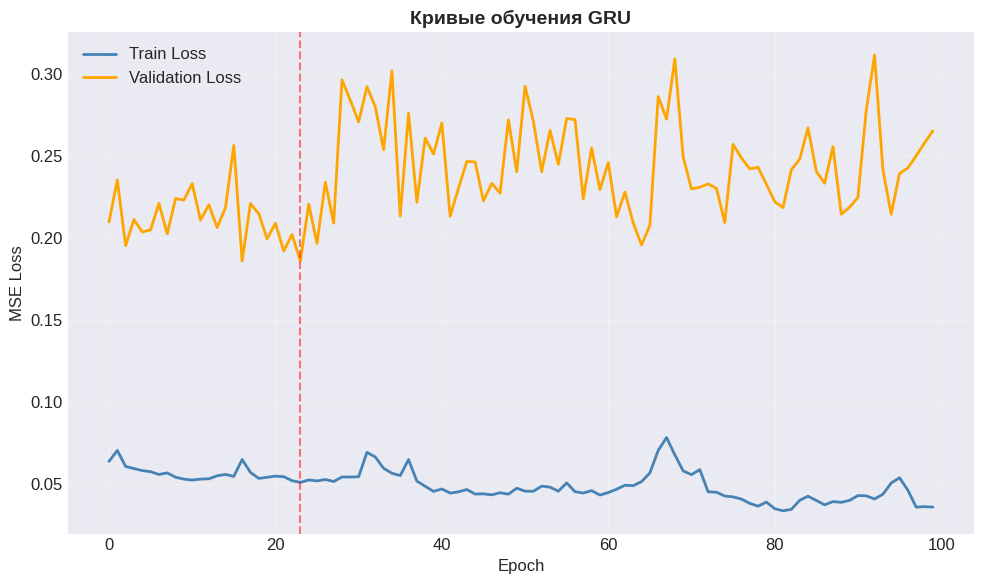

Лучшая эпоха: 24
Лучшая val loss: 0.185708


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_losses, label='Train Loss', linewidth=2, color='steelblue')
ax.plot(val_losses, label='Validation Loss', linewidth=2, color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Кривые обучения GRU', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axvline(x=np.argmin(val_losses), color='red', linestyle='--', alpha=0.5,
           label=f'Best epoch: {np.argmin(val_losses)+1}')

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Лучшая эпоха: {np.argmin(val_losses)+1}")
print(f"Лучшая val loss: {np.min(val_losses):.6f}")

**Оценка GRU на validation и test**

In [37]:
def evaluate_model_with_metrics(model, loader, scaler_y, device):
    """Оценка модели с вычислением метрик в исходном масштабе"""
    _, predictions_scaled, targets_scaled = evaluate(model, loader, criterion, device)

    # Обратное масштабирование
    predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    targets = scaler_y.inverse_transform(targets_scaled.reshape(-1, 1)).flatten()

    mae, rmse, mape = calculate_metrics(targets, predictions)
    return mae, rmse, mape, predictions, targets

# Оценка на validation
r1_val_mae, r1_val_rmse, r1_val_mape, r1_val_pred, r1_val_target = evaluate_model_with_metrics(
    model, val_loader, scaler_y, device
)

print("=== GRU (R1) - Validation ===")
print(f"MAE:  {r1_val_mae:.4f}")
print(f"RMSE: {r1_val_rmse:.4f}")
print(f"MAPE: {r1_val_mape:.2f}%")

# Оценка на test
r1_test_mae, r1_test_rmse, r1_test_mape, r1_test_pred, r1_test_target = evaluate_model_with_metrics(
    model, test_loader, scaler_y, device
)

print(f"\n=== GRU (R1) - Test ===")
print(f"MAE:  {r1_test_mae:.4f}")
print(f"RMSE: {r1_test_rmse:.4f}")
print(f"MAPE: {r1_test_mape:.2f}%")

=== GRU (R1) - Validation ===
MAE:  7.3643
RMSE: 9.3021
MAPE: 4.95%

=== GRU (R1) - Test ===
MAE:  9.6849
RMSE: 11.7432
MAPE: 6.11%


 **Создание runs.csv (таблица результатов)**

In [38]:
# Сбор всех результатов
results = pd.DataFrame([
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '60/20/20 temporal split',
        'window_size': '-',
        'horizon': 1,
        'model_summary': 'naive_last',
        'features_summary': 'no features',
        'scaler': 'none',
        'optimizer': '-',
        'lr': '-',
        'epochs_trained': '-',
        'best_val_mae': b1_val_mae,
        'best_val_rmse': b1_val_rmse,
        'best_val_mape': b1_val_mape,
        'test_mae': b1_test_mae,
        'test_rmse': b1_test_rmse,
        'test_mape': b1_test_mape,
        'notes': 'Naive baseline: прогноз = последнее значение из train'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '60/20/20 temporal split',
        'window_size': '7',
        'horizon': 1,
        'model_summary': 'moving_average',
        'features_summary': 'window_size=7',
        'scaler': 'none',
        'optimizer': '-',
        'lr': '-',
        'epochs_trained': '-',
        'best_val_mae': b2_val_mae,
        'best_val_rmse': b2_val_rmse,
        'best_val_mape': b2_val_mape,
        'test_mae': b2_test_mae,
        'test_rmse': b2_test_rmse,
        'test_mape': b2_test_mape,
        'notes': 'Moving average baseline: среднее последних 7 значений'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '60/20/20 temporal split',
        'window_size': '-',
        'horizon': 1,
        'model_summary': 'RidgeRegression',
        'features_summary': f'{len(feature_cols)} features (lags, rolling, calendar)',
        'scaler': 'StandardScaler',
        'optimizer': '-',
        'lr': '-',
        'epochs_trained': '-',
        'best_val_mae': b3_val_mae,
        'best_val_rmse': b3_val_rmse,
        'best_val_mape': b3_val_mape,
        'test_mae': b3_test_mae,
        'test_rmse': b3_test_rmse,
        'test_mape': b3_test_mape,
        'notes': f'Ridge regression with alpha={best_alpha}'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': '60/20/20 temporal split',
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': f'GRU_{hidden_size}_{num_layers}',
        'features_summary': f'{input_size} features',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': learning_rate,
        'epochs_trained': num_epochs,
        'best_val_mae': r1_val_mae,
        'best_val_rmse': r1_val_rmse,
        'best_val_mape': r1_val_mape,
        'test_mae': r1_test_mae,
        'test_rmse': r1_test_rmse,
        'test_mape': r1_test_mape,
        'notes': f'GRU with window_size={WINDOW_SIZE}, hidden={hidden_size}, layers={num_layers}'
    }
])

results.to_csv('artifacts/runs.csv', index=False)
print("Результаты сохранены в artifacts/runs.csv")
print("\n=== Сравнение моделей ===")
print(results[['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape']].to_string(index=False))

Результаты сохранены в artifacts/runs.csv

=== Сравнение моделей ===
experiment_id  best_val_mae  best_val_rmse  best_val_mape
           B1     24.256494      28.557493      15.839840
           B2     15.273385      18.407157      10.689930
           B3      4.724928       6.018680       3.289552
           R1      7.364326       9.302075       4.945947


**Сравнение моделей (baselines_compare.png)**

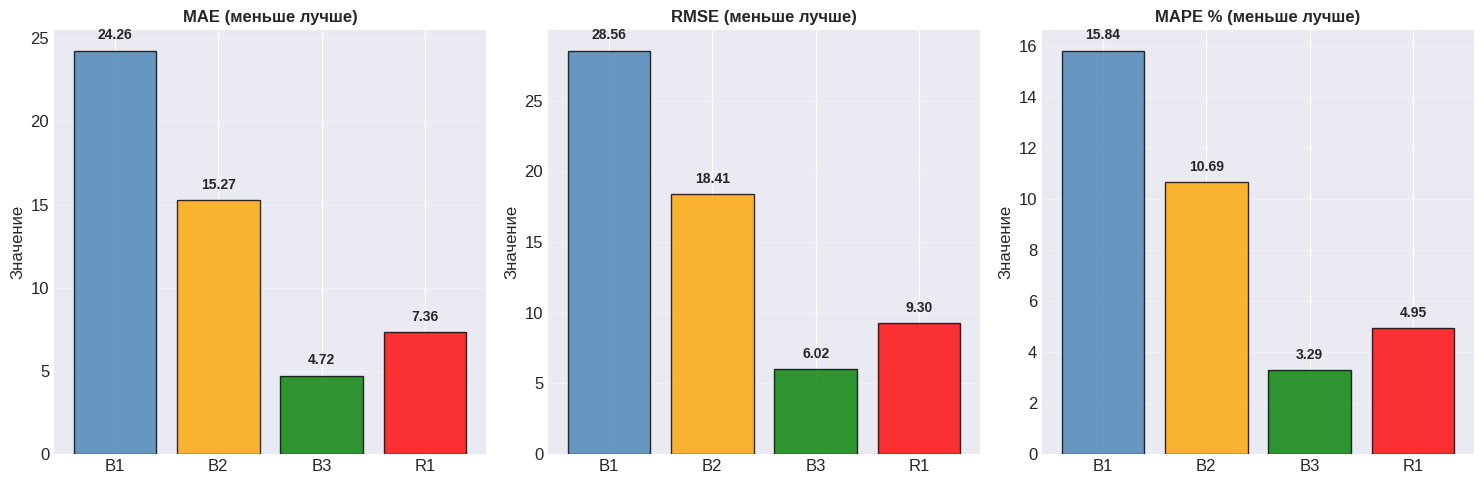

График сравнения моделей сохранен в artifacts/figures/baselines_compare.png

=== Лучшая модель по validation ===
Лучшая модель: B3
Validation MAE: 4.7249
Validation RMSE: 6.0187
Validation MAPE: 3.29%

Test результаты лучшей модели:
Test MAE: 4.8958
Test RMSE: 6.2174
Test MAPE: 3.17%


In [39]:
#Сравнение моделей (baselines_compare.png)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['best_val_mae', 'best_val_rmse', 'best_val_mape']
titles = ['MAE (меньше лучше)', 'RMSE (меньше лучше)', 'MAPE % (меньше лучше)']
colors = ['steelblue', 'orange', 'green', 'red']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    values = results[metric].values
    bars = ax.bar(results['experiment_id'], values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3, axis='y')

    # Добавление значений на столбцы
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сравнения моделей сохранен в artifacts/figures/baselines_compare.png")
print("\n=== Лучшая модель по validation ===")
best_model = results.loc[results['best_val_mae'].idxmin()]
print(f"Лучшая модель: {best_model['experiment_id']}")
print(f"Validation MAE: {best_model['best_val_mae']:.4f}")
print(f"Validation RMSE: {best_model['best_val_rmse']:.4f}")
print(f"Validation MAPE: {best_model['best_val_mape']:.2f}%")
print(f"\nTest результаты лучшей модели:")
print(f"Test MAE: {best_model['test_mae']:.4f}")
print(f"Test RMSE: {best_model['test_rmse']:.4f}")
print(f"Test MAPE: {best_model['test_mape']:.2f}%")

 **График лучшего прогноза на test (best_forecast_test.png)**

=== Лучшая модель: B3 ===


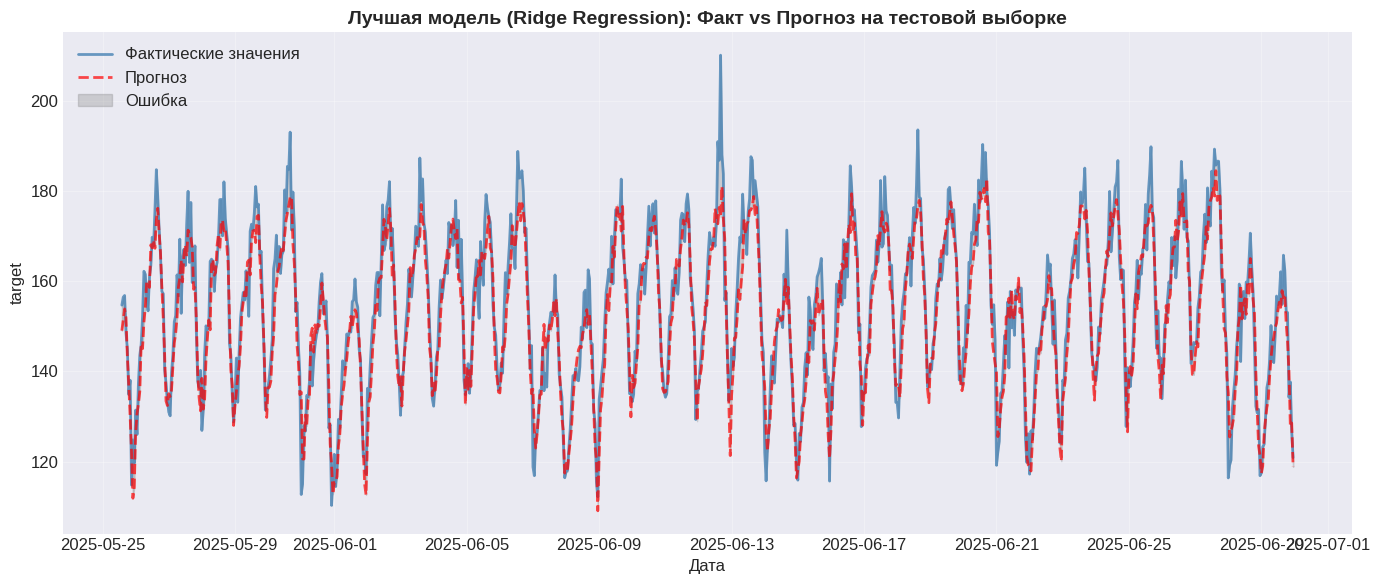

График прогноза лучшей модели сохранен в artifacts/figures/best_forecast_test.png

Финальные метрики лучшей модели (Ridge Regression) на test:
  MAE:  4.8958
  RMSE: 6.2174
  MAPE: 3.17%


In [40]:
#График лучшего прогноза на test

# Определяем лучшую модель по validation
best_model_id = results.loc[results['best_val_mae'].idxmin(), 'experiment_id']

print(f"=== Лучшая модель: {best_model_id} ===")

# Выбираем прогноз лучшей модели
if best_model_id == 'B1':
    best_test_pred = b1_test_pred
    best_test_target = y_test.values
    model_name = "Naive Baseline"
elif best_model_id == 'B2':
    best_test_pred = b2_test_pred
    best_test_target = y_test.values
    model_name = "Moving Average Baseline"
elif best_model_id == 'B3':
    best_test_pred = b3_test_pred
    best_test_target = y_test.values
    model_name = "Ridge Regression"
else:  # R1
    best_test_pred = r1_test_pred
    best_test_target = r1_test_target
    model_name = "GRU"

# Создаем даты для test (только те, для которых есть прогнозы)
if best_model_id == 'R1':
    # Для GRU прогнозы на тесте имеют длину len(test_dataset)
    test_dates = test_features['date'].iloc[WINDOW_SIZE:].values
else:
    test_dates = test_features['date'].values

# График
fig, ax = plt.subplots(figsize=(14, 6))

# Обрезаем до одинаковой длины
min_len = min(len(test_dates), len(best_test_target), len(best_test_pred))
test_dates = test_dates[:min_len]
best_test_target = best_test_target[:min_len]
best_test_pred = best_test_pred[:min_len]

ax.plot(test_dates, best_test_target, label='Фактические значения', color='steelblue', linewidth=2, alpha=0.8)
ax.plot(test_dates, best_test_pred, label='Прогноз', color='red', linewidth=2, alpha=0.7, linestyle='--')
ax.fill_between(test_dates, best_test_target, best_test_pred, alpha=0.3, color='gray', label='Ошибка')

ax.set_title(f'Лучшая модель ({model_name}): Факт vs Прогноз на тестовой выборке',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"График прогноза лучшей модели сохранен в artifacts/figures/best_forecast_test.png")

# Дополнительная метрика
mae_best, rmse_best, mape_best = calculate_metrics(best_test_target, best_test_pred)
print(f"\nФинальные метрики лучшей модели ({model_name}) на test:")
print(f"  MAE:  {mae_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")
print(f"  MAPE: {mape_best:.2f}%")